In [ ]:
!pip install python-sat matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.9 MB/s eta 0:00:00


In [ ]:
class CSPProblem:
    """
    Represents the CSP coloring puzzle.
    Each cell is either blank (None) or holds an integer k >= 0.
    Variables: each cell (i, j) -> domain {True=GREEN, False=RED}.
    Constraint: for each numbered cell, exactly k of its 9 neighbors are green.
    """
    def __init__(self, matrix: list[list]):
        """
        matrix: 2D list of int or None (None = blank cell).
        """
        self.matrix = matrix
        self.rows = len(matrix)
        self.cols = len(matrix[0]) if self.rows > 0 else 0
    def get_value(self, r, c):
        return self.matrix[r][c]
    def is_blank(self, r, c) -> bool:
        return self.matrix[r][c] is None
    def neighbors(self, r, c) -> list[tuple[int, int]]:
        """
        Return all valid neighbors of (r, c) including itself (9-adjacency).
        Cells at borders have fewer neighbors.
        """
        result = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < self.rows and 0 <= nc < self.cols:
                    result.append((nr, nc))
        return result
    def numbered_cells(self) -> list[tuple[int, int, int]]:
        """Danh sách (r, c, k) cho mọi ô có số."""
        return [
            (r, c, self.matrix[r][c])
            for r in range(self.rows)
            for c in range(self.cols)
            if not self.is_blank(r, c)
        ]

    def describe_constraints(self) -> list[str]:
        lines = []
        lines.append(" CSP Constraints (Task 3 – Requirement 1)")
        lines.append("Domain : each cell in {GREEN = True, RED = False}")
        lines.append("")

        lines.append("Type 1 Numbered cell constraint (interior):")
        lines.append("  For each cell (r,c) with value k and 9 neighbors,")
        lines.append("  exactly k of those neighbors must be GREEN.")
        lines.append("  CNF encoding: at-least-k(N) \u2227 at-most-k(N)")
        example_shown = False
        for r, c, k in self.numbered_cells():
            if len(self.neighbors(r, c)) == 9:
                lines.append(f"  Example: Cell ({r},{c}) = {k}  \u2192  9 neighbors, exactly {k} must be GREEN.")
                example_shown = True
                break
        if not example_shown:
            lines.append("  (No interior numbered cell in this matrix.)")
        lines.append("")

        lines.append("Type 2 \u2013 Border/corner cell constraint:")
        lines.append("  Cells on the border have fewer than 9 neighbors (edge: 6, corner: 4).")
        example_shown = False
        for r, c, k in self.numbered_cells():
            nbrs = self.neighbors(r, c)
            if len(nbrs) < 9:
                pos = "corner" if len(nbrs) == 4 else "edge"
                lines.append(f"  Example: Cell ({r},{c}) = {k}  \u2192  {len(nbrs)} neighbors ({pos}), exactly {k} must be GREEN.")
                example_shown = True
                break
        if not example_shown:
            lines.append("  (No border numbered cell in this matrix.)")
        lines.append("")

        lines.append("Type 3 \u2013 Blank cell (no constraint):")
        blank_found = False
        for r in range(self.rows):
            for c in range(self.cols):
                if self.is_blank(r, c):
                    lines.append(f"  Example: Cell ({r},{c}) is blank 2  no constraint generated.")
                    blank_found = True
                    break
            if blank_found:
                break
        lines.append("")
        numbered = self.numbered_cells()
        n_interior = sum(1 for r, c, _ in numbered if len(self.neighbors(r, c)) == 9)
        n_border   = len(numbered) - n_interior
        n_blank    = sum(1 for r in range(self.rows) for c in range(self.cols) if self.is_blank(r, c))
        lines.append("Summary:")
        lines.append(f"  Interior numbered cells : {n_interior}")
        lines.append(f"  Border/corner numbered  : {n_border}")
        lines.append(f"  Blank cells             : {n_blank}")
        return lines

    @staticmethod
    def load_from_file(path: str):
        matrix = []
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                row = [None if t == '.' else int(t) for t in line.split()]
                matrix.append(row)
        return CSPProblem(matrix)

In [ ]:
from itertools import combinations

class CNFEncoder:
    """
    Variable numbering (1-indexed, required by PySAT):
        var(r, c) = r * cols + c + 1
    For each numbered cell (r, c) with value k and neighbor list N:
        Exactly-k(N) = at-least-k(N) AND at-most-k(N)
    at-least-k(N, k):
        For every subset S of N with |S| = |N|-k+1,
        at least one cell in S must be GREEN.
        => Clause: (OR of vars in S)
        Explanation: if fewer than k cells were green, some (|N|-k+1)-subset
        would be all red — this clause blocks that.
    at-most-k(N, k):
        For every subset S of N with |S| = k+1,s
        at least one cell in S must be RED (not all green).
        => Clause: (OR of NEG vars in S)
    """
    def __init__(self, problem: CSPProblem):
        self.problem = problem
        self.rows = problem.rows
        self.cols = problem.cols
        self.clauses: list[list[int]] = []
        self._clause_set: set[frozenset] = set()
    def var(self, r: int, c: int) -> int:
        return r * self.cols + c + 1

    def _add_clause(self, clause: list[int]) -> None:
        key = frozenset(clause)
        if key not in self._clause_set:
            self._clause_set.add(key)
            self.clauses.append(clause)

    def _encode_at_least(self, var_list: list[int], k: int) -> None:
        n = len(var_list)
        size = n - k + 1
        if size <= 0:
            return
        for subset in combinations(var_list, size):
            self._add_clause(list(subset))

    def _encode_at_most(self, var_list: list[int], k: int) -> None:
        for subset in combinations(var_list, k + 1):
            self._add_clause([-v for v in subset])

    def encode(self) -> list[list[int]]:

        self.clauses = []
        self._clause_set = set()

        for r, c, k in self.problem.numbered_cells():
            nbrs = self.problem.neighbors(r, c)
            var_list = [self.var(nr, nc) for (nr, nc) in nbrs]
            n = len(var_list)
            if k < 0 or k > n:
                raise ValueError(f"Cell ({r},{c}) has value {k} but only {n} neighbors.")
            self._encode_at_least(var_list, k)
            self._encode_at_most(var_list, k)

        return self.clauses

    def num_variables(self) -> int:
        return self.rows * self.cols

    def decode(self, model: list[int]) -> list[list[bool]]:
        """
        Convert PySAT model (list of signed ints) to a 2D bool grid.
        True  -> GREEN
        False -> RED
        """
        true_vars = set(v for v in model if v > 0)
        return [
            [self.var(r, c) in true_vars for c in range(self.cols)]
            for r in range(self.rows)
        ]

In [ ]:
from pysat.solvers import Glucose3

class CSPSolver:
    """
    Wraps PySAT Glucose3 to solve the encoded CSP.
    """
    def __init__(self, problem: CSPProblem):
        self.problem = problem
        self.encoder = CNFEncoder(problem)
        self._solution: list[list[bool]] | None = None
        self._sat: bool = False
    def solve(self) -> bool:
        """
        Encode and solve the CSP.
        Returns True if satisfiable, False otherwise.
        """
        clauses = self.encoder.encode()
        solver = Glucose3()
        solver.append_formula(clauses)
        self._sat = solver.solve()
        if self._sat:
            self._solution = self.encoder.decode(solver.get_model())
        solver.delete()
        return self._sat

    @property
    def is_satisfiable(self) -> bool:
        return self._sat

    @property
    def solution(self) -> list[list[bool]] | None:
        """2D grid: True=GREEN, False=RED. None if unsatisfiable."""
        return self._solution
    def clause_count(self) -> int:
        return len(self.encoder.clauses)

    def variable_count(self) -> int:
        return self.encoder.num_variables()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
class Visualizer:
    """
    Renders the CSP input matrix and the colored solution side-by-side
    using matplotlib.
    GREEN cells  -> bright green (#4CAF50)
    RED cells    -> crimson     (#E53935)
    Blank cells  -> light gray  (#EEEEEE)
    """
    GREEN      = "#4CAF50"
    RED        = "#E53935"
    BLANK      = "#EEEEEE"
    TEXT_DARK  = "#1A1A1A"
    TEXT_LIGHT = "#FFFFFF"
    def __init__(self, problem: CSPProblem):
        self.problem = problem

    def _cell_color(self, r, c, solution):
        if solution is None:
            return self.BLANK
        return self.GREEN if solution[r][c] else self.RED

    def _draw_grid(self, ax, solution, title):
        rows, cols = self.problem.rows, self.problem.cols
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
        ax.set_aspect("equal")
        ax.axis("off")
        ax.set_title(title, fontsize=13, pad=8)
        for r in range(rows):
            for c in range(cols):
                color = self._cell_color(r, c, solution)
                rect = mpatches.FancyBboxPatch(
                    (c + 0.04, rows - r - 1 + 0.04), 0.92, 0.92,
                    boxstyle="round,pad=0.05",
                    facecolor=color, edgecolor="#555555", linewidth=0.6,
                )
                ax.add_patch(rect)
                val = self.problem.get_value(r, c)
                if val is not None:
                    txt_color = self.TEXT_LIGHT if color in (self.GREEN, self.RED) else self.TEXT_DARK
                    ax.text(
                        c + 0.5, rows - r - 0.5, str(val),
                        ha="center", va="center",
                        fontsize=max(7, min(14, 120 // max(rows, cols))),
                        fontweight="bold", color=txt_color,
                    )
    def show(self, solution=None, save_path=None):
        n_plots = 1 if solution is None else 2
        fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
        if n_plots == 1:
            axes = [axes]
        self._draw_grid(axes[0], None, "Input matrix")
        if solution is not None:
            self._draw_grid(axes[1], solution, "Solution")
        fig.legend(
            handles=[
                mpatches.Patch(color=self.GREEN, label="GREEN"),
                mpatches.Patch(color=self.RED,   label="RED"),
                mpatches.Patch(color=self.BLANK, label="Blank"),
            ],
            loc="lower center", ncol=3, fontsize=10,
            frameon=False, bbox_to_anchor=(0.5, -0.02),
        )
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"Figure saved to {save_path}")
        else:
            plt.show()
        plt.close(fig)

In [ ]:
DEMO_MATRIX = [
    [None, 2,    3,    None, None, 0,    None, None, None, None],
    [None, None, None, None, 3,    None, 2,    None, None, 6   ],
    [None, None, 5,    None, 5,    3,    None, 5,    7,    4   ],
    [None, 4,    None, 5,    None, 5,    None, 6,    None, 3   ],
    [None, None, 4,    None, 5,    None, 6,    None, None, 3   ],
    [None, None, None, 2,    None, 5,    None, None, None, None],
    [4,    None, 1,    None, None, None, 1,    1,    None, None],
    [4,    None, 1,    None, None, None, 1,    None, 4,    None],
    [None, None, None, None, 6,    None, None, None, None, 4   ],
    [None, 4,    4,    None, None, None, None, 4,    None, None],
]
problem = CSPProblem(DEMO_MATRIX)
print(f"MaTrix: {problem.rows}×{problem.cols}")
print("\n".join(problem.describe_constraints()))

MaTrix: 10×10
 CSP Constraints (Task 3 – Requirement 1)
Domain : each cell in {GREEN = True, RED = False}

Type 1 Numbered cell constraint (interior):
  For each cell (r,c) with value k and 9 neighbors,
  exactly k of those neighbors must be GREEN.
  CNF encoding: at-least-k(N) ∧ at-most-k(N)
  Example: Cell (1,4) = 3  →  9 neighbors, exactly 3 must be GREEN.

Type 2 – Border/corner cell constraint:
  Cells on the border have fewer than 9 neighbors (edge: 6, corner: 4).
  Example: Cell (0,1) = 2  →  6 neighbors (edge), exactly 2 must be GREEN.

Type 3 – Blank cell (no constraint):
  Example: Cell (0,0) is blank 2  no constraint generated.

Summary:
  Interior numbered cells : 23
  Border/corner numbered  : 13
  Blank cells             : 64


Variable     : 100
Clause : 3607


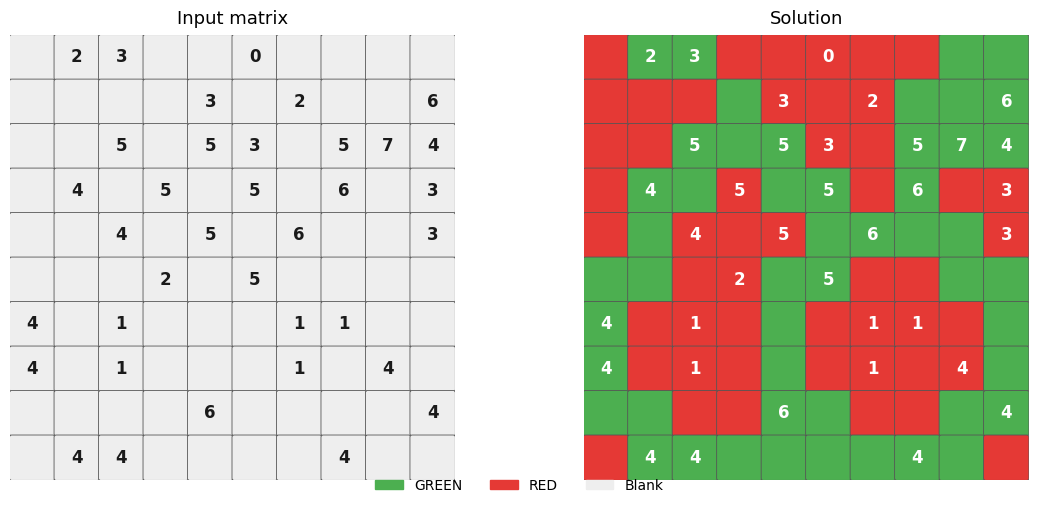

In [ ]:
solver = CSPSolver(problem)
sat    = solver.solve()

print(f"Variable     : {solver.variable_count()}")
print(f"Clause : {solver.clause_count()}")

viz = Visualizer(problem)
viz.show(solver.solution)